In [43]:
from collections import defaultdict
from pathlib import Path
import csv
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_PATH = Path("results/benchmark_results.csv")

df = pd.read_csv(RESULTS_PATH)

df["N"] = pd.to_numeric(df["N"], errors="coerce")
df["P"] = pd.to_numeric(df["P"], errors="coerce")
df["PARTITION_TIME"] = pd.to_numeric(df["PARTITION_TIME"], errors="coerce")
df["GLOBAL_TIME"] = pd.to_numeric(df["GLOBAL_TIME"], errors="coerce")

exec_type_names = sorted(df["EXEC_TYPE"].dropna().unique())
exec_type_palette = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple",
    "tab:brown",
    "tab:pink",
    "tab:gray",
    "tab:olive",
    "tab:cyan",
]
exec_type_colors = {
    exec_type: exec_type_palette[idx % len(exec_type_palette)]
    for idx, exec_type in enumerate(exec_type_names)
}

print(f"[Loaded {df.shape[0]} different runs from {RESULTS_PATH}]\n")
print("Distinct values for each column:")
print(f"  EXEC_TYPE: {df['EXEC_TYPE'].unique()}")
print(f"  HASH: {df['HASH'].unique()}")
print(f"  N: {df['N'].unique()}")
print(f"  P: {df['P'].unique()}")

[Loaded 280 different runs from results/benchmark_results.csv]

Distinct values for each column:
  EXEC_TYPE: ['plain_novec' 'plain_vec' 'avx2']
  HASH: ['mask' 'xorshift' 'fmix32fold']
  N: [   10000   100000  1000000 10000000]
  P: [512]


# Checksum validation

In [44]:
summary_rows = []
df_grouped = df.groupby(["N", "P", "HASH"])
valid_counter = 0
for (N, P, HASH), subdf in df_grouped:
    checksums = subdf["CHECKSUM"].unique()
    is_valid = len(checksums) == 1
    valid_counter += 1 if is_valid else 0

    summary_rows.append({
        "N": N,
        "P": P,
        "HASH": HASH,
        "N_CHECKSUMS": len(checksums),
        "CHECKSUMS": ", ".join(map(str, checksums))
    })

if valid_counter == df_grouped.ngroups:
    print(f"[OK] All groups have a single unique checksum")
else:
    print(f"[FAIL] Only {valid_counter}/{df_grouped.ngroups} groups have a single unique checksum")

checksum_validation_df = pd.DataFrame(summary_rows)
checksum_validation_df


[OK] All groups have a single unique checksum


,N,P,HASH,N_CHECKSUMS,CHECKSUMS
0,10000,512,fmix32fold,1,65795765592199590226285493688544336861
1,10000,512,mask,1,1401388889654117033201764478318212387
2,10000,512,xorshift,1,159585862345277033473532649390500881634
3,100000,512,fmix32fold,1,119391814101996707215792430577907033249
4,100000,512,mask,1,58615451481728545542137311502802293713
5,100000,512,xorshift,1,75414008876171601096065495345062203897
6,1000000,512,fmix32fold,1,1049445613346634757810256373715620250023
7,1000000,512,mask,1,766527569858792240010144027885537090316
8,1000000,512,xorshift,1,113139716036919870564921956491651946003
9,10000000,512,fmix32fold,1,109755882100909620748295953279334279890


# Averaging

In [45]:
group_columns = ["N", "P", "HASH", "EXEC_TYPE", "CHECKSUM"]
avg_columns = [
    col for col in df.columns
    if col not in group_columns and pd.api.types.is_numeric_dtype(df[col])
]

# Collapse repeated runs and keep one averaged row for each stable configuration
stable_avg_df = (
    df.groupby(group_columns, as_index=False)
    .agg({col: "mean" for col in avg_columns})
    .rename(columns={col: f"AVG_{col}" for col in avg_columns})
    .sort_values(group_columns)
    .reset_index(drop=True)
)

stable_avg_df.head(10)


,N,P,HASH,EXEC_TYPE,CHECKSUM,AVG_THROUGHPUT,AVG_PARTITION_TIME,AVG_GLOBAL_TIME
0,10000,512,fmix32fold,plain_novec,65795765592199590226285493688544336861,4.564297e+08,0.000044,1.209220
1,10000,512,fmix32fold,plain_vec,65795765592199590226285493688544336861,7.541453e+08,0.000027,1.205659
2,10000,512,mask,avx2,1401388889654117033201764478318212387,1.207931e+09,0.000017,1.238245
3,10000,512,mask,plain_novec,1401388889654117033201764478318212387,9.500756e+08,0.000021,1.409707
4,10000,512,mask,plain_vec,1401388889654117033201764478318212387,1.071213e+09,0.000019,1.257107
5,10000,512,xorshift,plain_novec,159585862345277033473532649390500881634,6.913706e+08,0.000029,1.217445
6,10000,512,xorshift,plain_vec,159585862345277033473532649390500881634,8.382385e+08,0.000024,1.207416
7,100000,512,fmix32fold,plain_novec,119391814101996707215792430577907033249,4.618110e+08,0.000433,1.230616
8,100000,512,fmix32fold,plain_vec,119391814101996707215792430577907033249,7.922326e+08,0.000252,1.241926
9,100000,512,mask,avx2,58615451481728545542137311502802293713,1.197132e+09,0.000168,1.212136


# Partition time

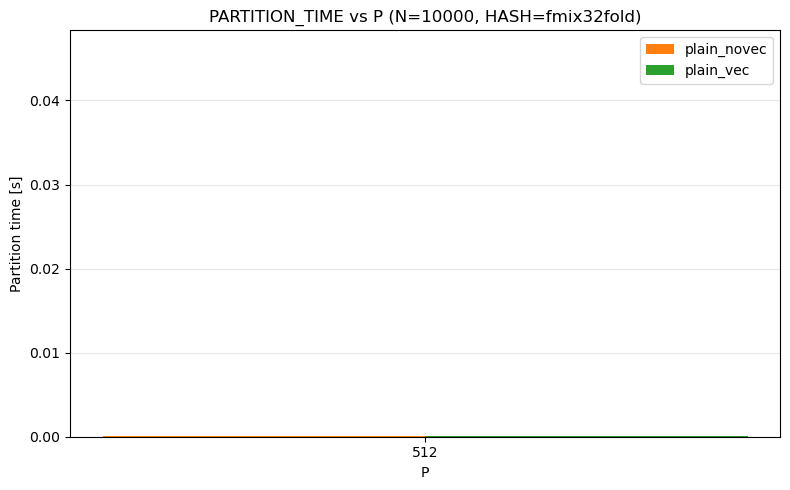

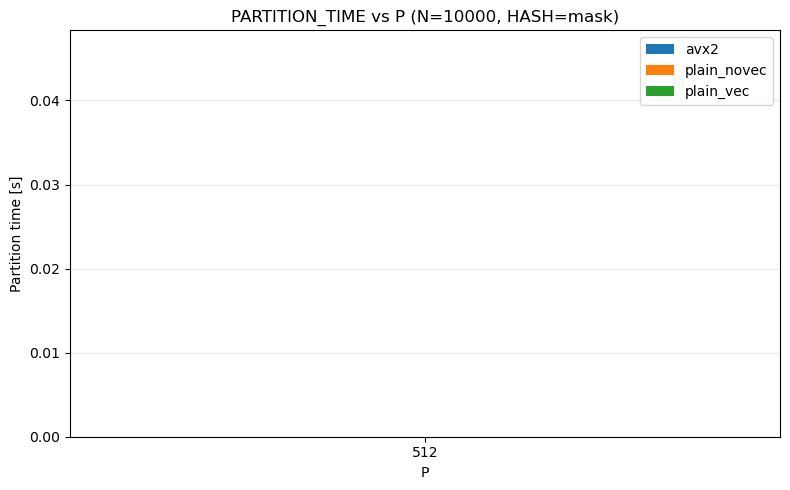

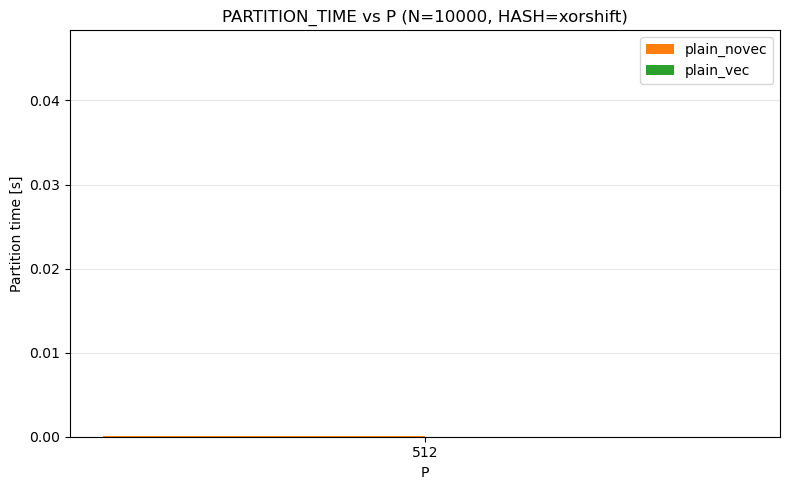

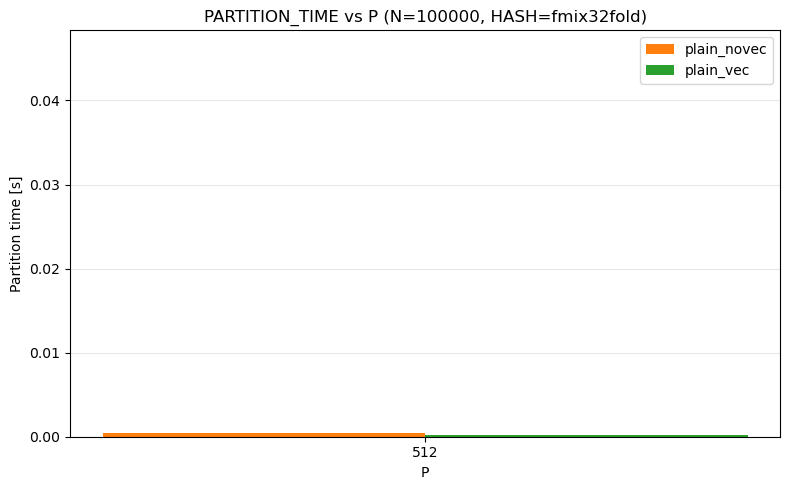

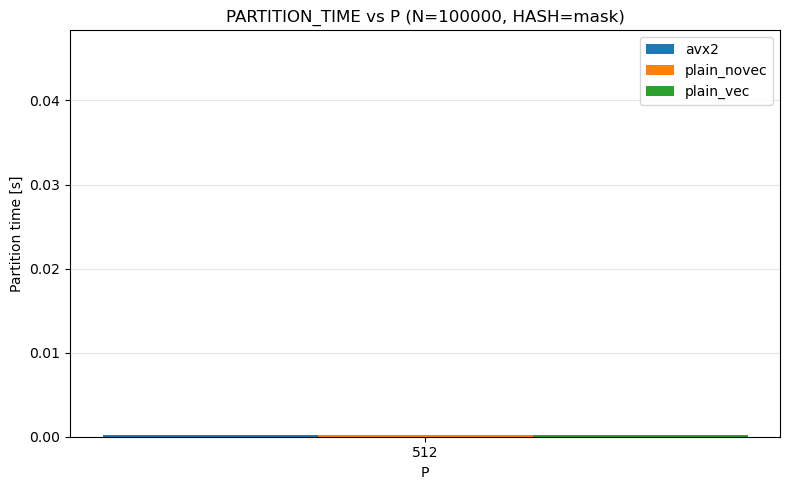

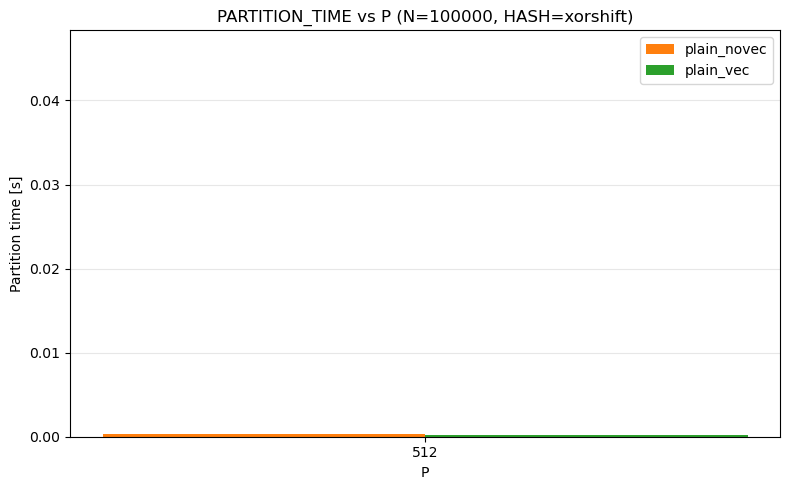

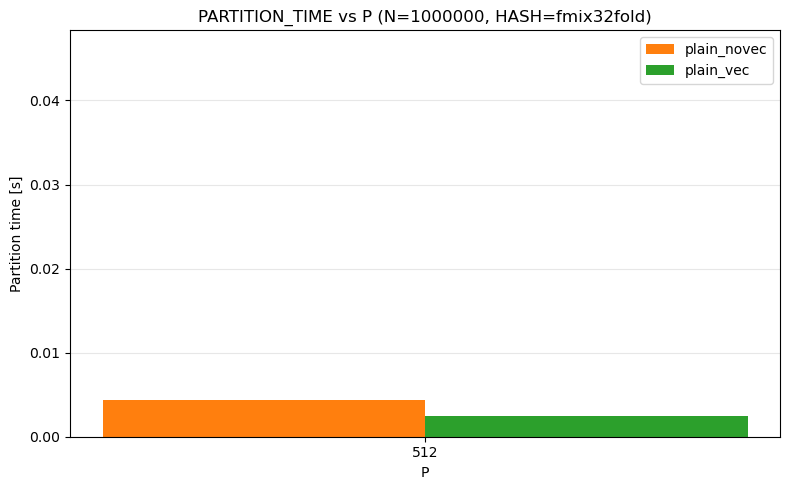

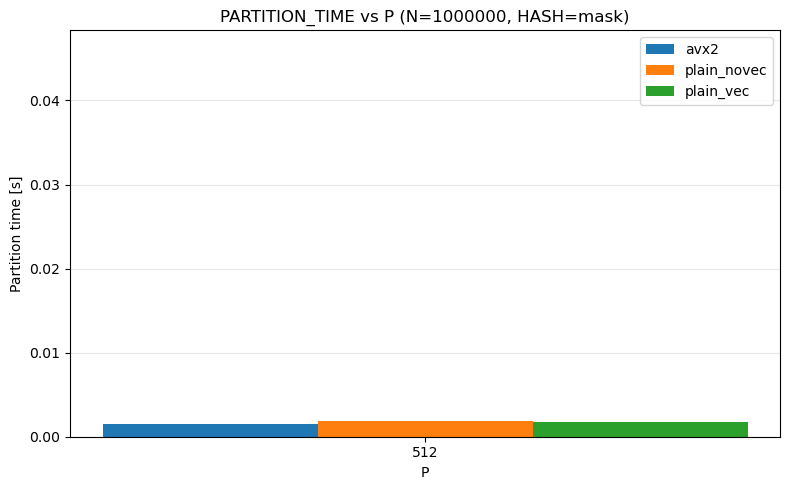

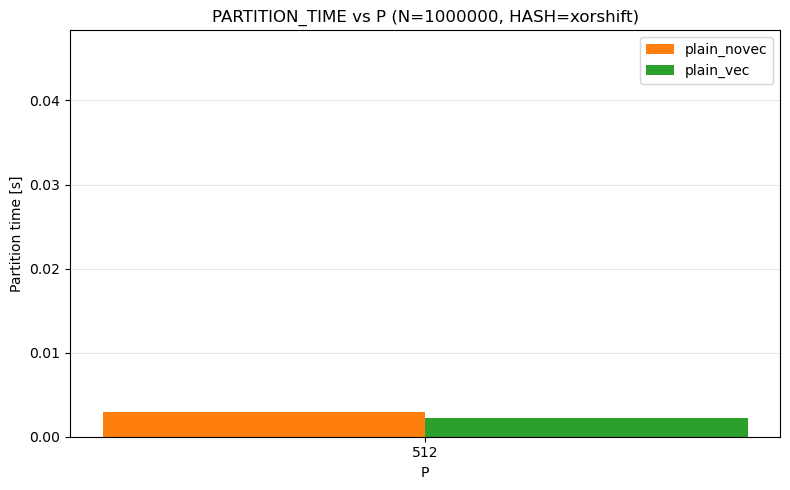

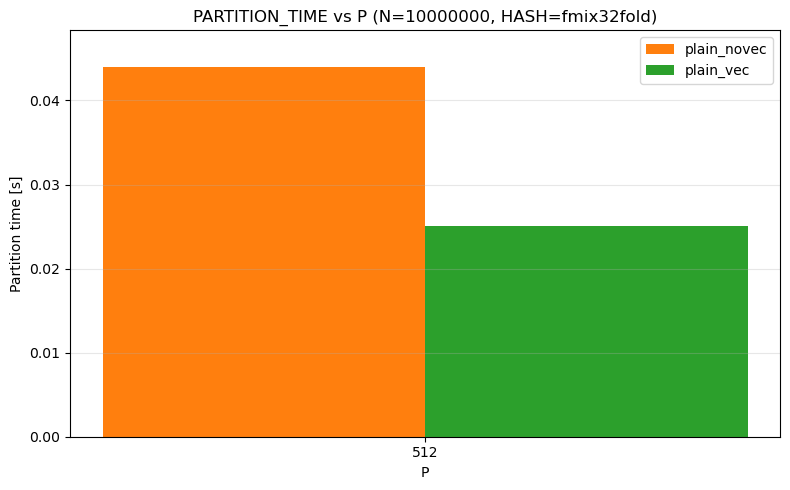

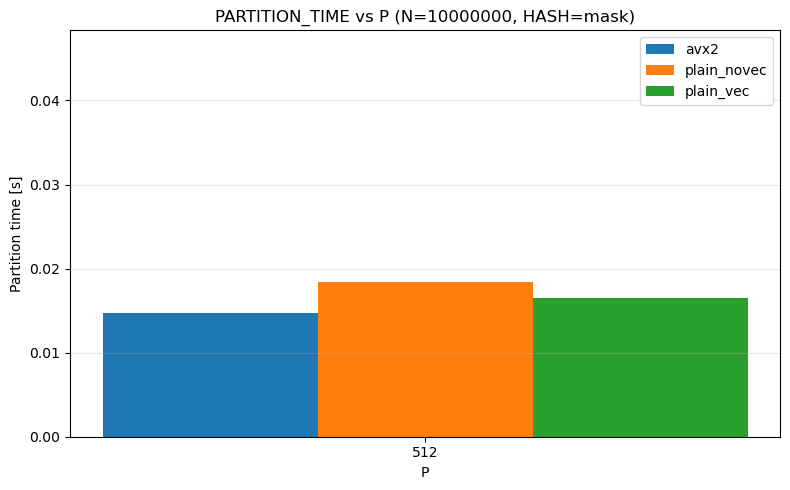

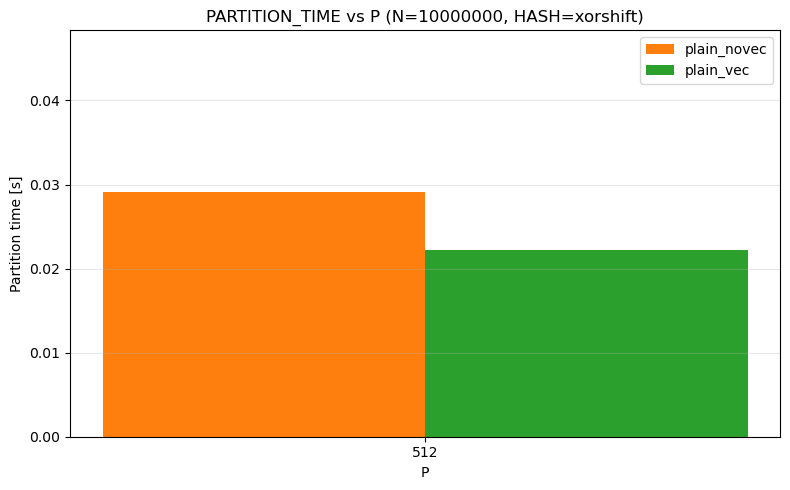

In [46]:
GLOBAL_PARTITION_TIME_YMAX = stable_avg_df["AVG_PARTITION_TIME"].max()
for (fixed_N, fixed_HASH), subdf in stable_avg_df.groupby(["N", "HASH"]):
    plt.figure(figsize=(8, 5))

    p_values = sorted(subdf["P"].unique())
    x_positions = list(range(len(p_values)))
    exec_types = sorted(subdf["EXEC_TYPE"].dropna().unique())

    if not exec_types:
        continue

    bar_width = 0.8 / len(exec_types)

    for idx, exec_type in enumerate(exec_types):
        g = subdf[subdf["EXEC_TYPE"] == exec_type].sort_values("P")
        values_by_p = g.set_index("P")["AVG_PARTITION_TIME"].to_dict()
        heights = [values_by_p.get(p, float("nan")) for p in p_values]
        offsets = [
            x + (idx - (len(exec_types) - 1) / 2) * bar_width
            for x in x_positions
        ]

        plt.bar(
            offsets,
            heights,
            width=bar_width,
            color=exec_type_colors.get(exec_type, "tab:gray"),
            label=exec_type,
        )

    if GLOBAL_PARTITION_TIME_YMAX > 0:
        plt.ylim(0, GLOBAL_PARTITION_TIME_YMAX * 1.1)

    plt.xticks(x_positions, p_values)
    plt.xlabel("P")
    plt.ylabel("Partition time [s]")
    plt.title(f"PARTITION_TIME vs P (N={fixed_N}, HASH={fixed_HASH})")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Speedup

In [47]:
# Use the averaged throughput of plain_novec as the reference for speedup.
baseline_exec_type = "plain_novec"
baseline_df = (
    stable_avg_df[stable_avg_df["EXEC_TYPE"] == baseline_exec_type][
        ["N", "P", "HASH", "CHECKSUM", "AVG_PARTITION_TIME"]
    ]
    .rename(columns={"AVG_PARTITION_TIME": "BASELINE_AVG_PARTITION_TIME"})
)
speedup_avg_df = stable_avg_df.merge(
    baseline_df,
    on=["N", "P", "HASH", "CHECKSUM"],
    how="left",
)
speedup_avg_df["SPEEDUP"] = (
    round(speedup_avg_df["BASELINE_AVG_PARTITION_TIME"] / speedup_avg_df["AVG_PARTITION_TIME"], 2)
)

speedup_avg_df.head(10)

,N,P,HASH,EXEC_TYPE,CHECKSUM,AVG_THROUGHPUT,AVG_PARTITION_TIME,AVG_GLOBAL_TIME,BASELINE_AVG_PARTITION_TIME,SPEEDUP
0,10000,512,fmix32fold,plain_novec,65795765592199590226285493688544336861,4.564297e+08,0.000044,1.209220,0.000044,1.00
1,10000,512,fmix32fold,plain_vec,65795765592199590226285493688544336861,7.541453e+08,0.000027,1.205659,0.000044,1.65
2,10000,512,mask,avx2,1401388889654117033201764478318212387,1.207931e+09,0.000017,1.238245,0.000021,1.27
3,10000,512,mask,plain_novec,1401388889654117033201764478318212387,9.500756e+08,0.000021,1.409707,0.000021,1.00
4,10000,512,mask,plain_vec,1401388889654117033201764478318212387,1.071213e+09,0.000019,1.257107,0.000021,1.13
5,10000,512,xorshift,plain_novec,159585862345277033473532649390500881634,6.913706e+08,0.000029,1.217445,0.000029,1.00
6,10000,512,xorshift,plain_vec,159585862345277033473532649390500881634,8.382385e+08,0.000024,1.207416,0.000029,1.21
7,100000,512,fmix32fold,plain_novec,119391814101996707215792430577907033249,4.618110e+08,0.000433,1.230616,0.000433,1.00
8,100000,512,fmix32fold,plain_vec,119391814101996707215792430577907033249,7.922326e+08,0.000252,1.241926,0.000433,1.72
9,100000,512,mask,avx2,58615451481728545542137311502802293713,1.197132e+09,0.000168,1.212136,0.000199,1.19


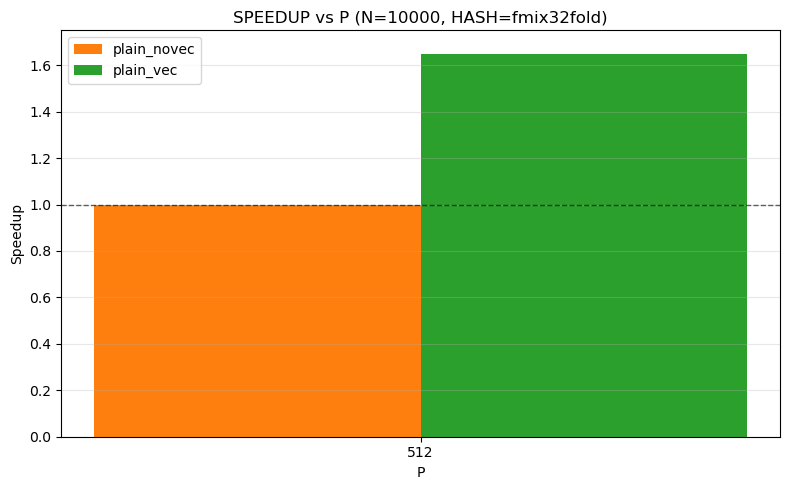

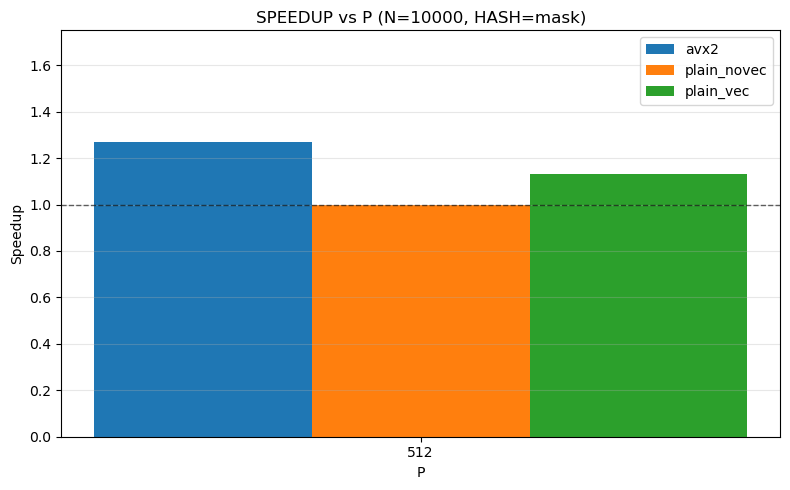

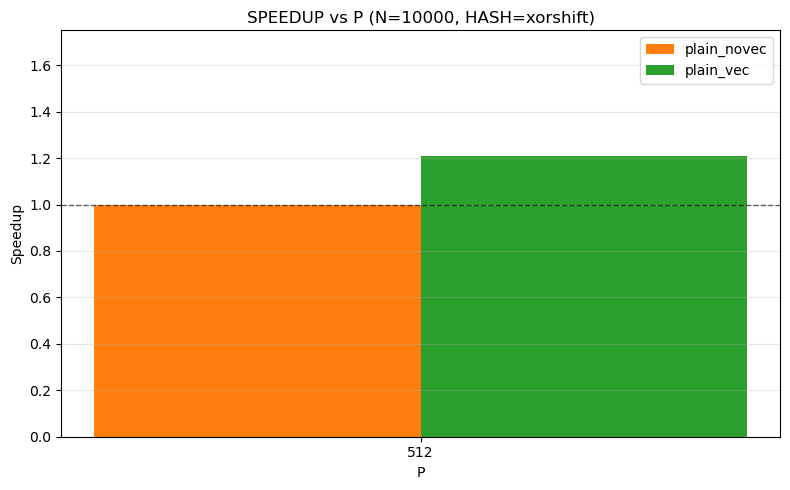

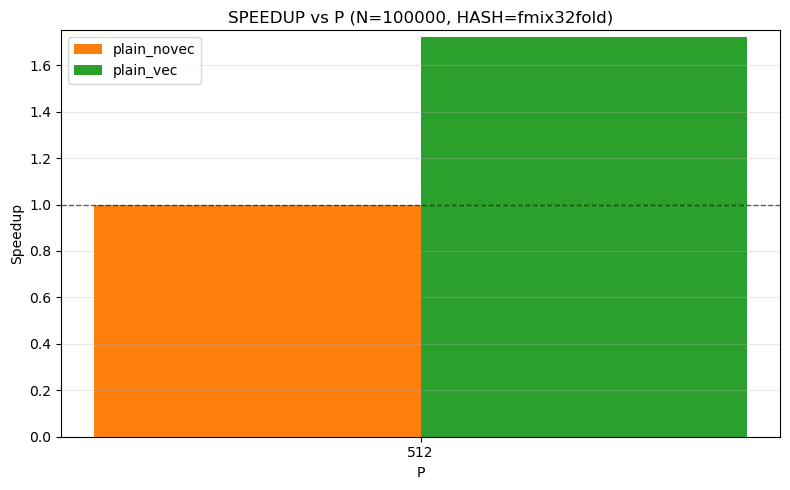

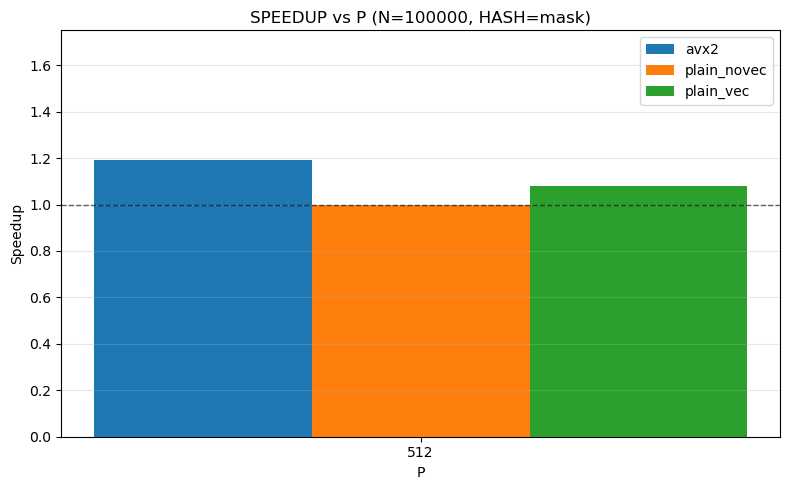

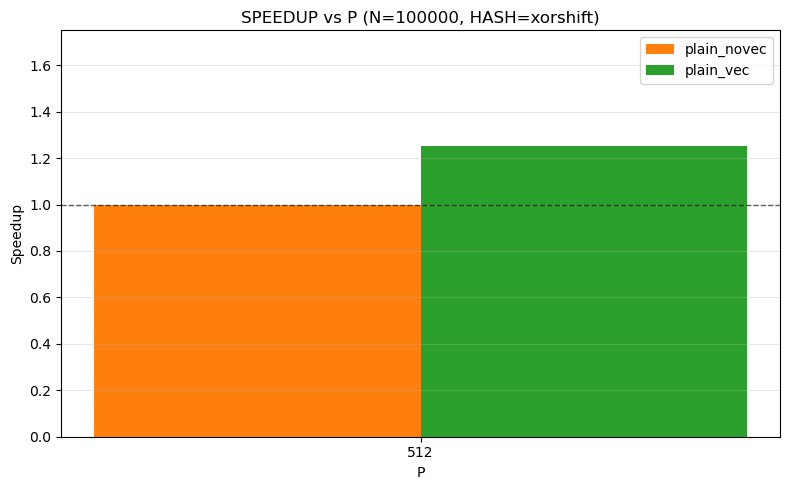

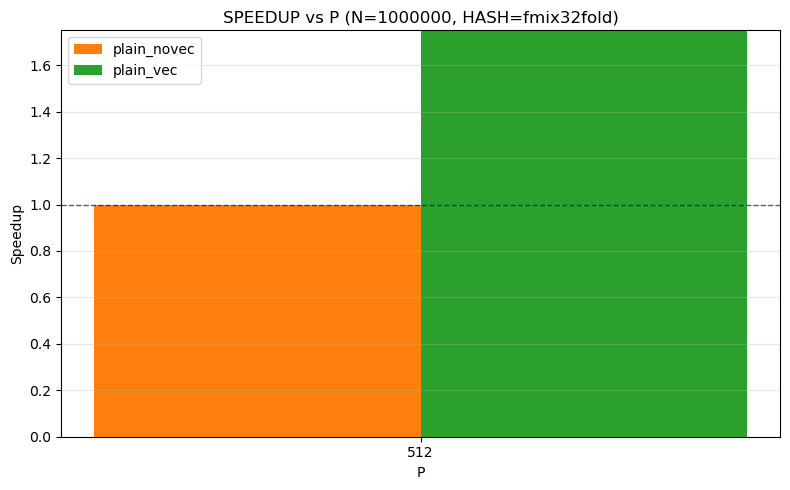

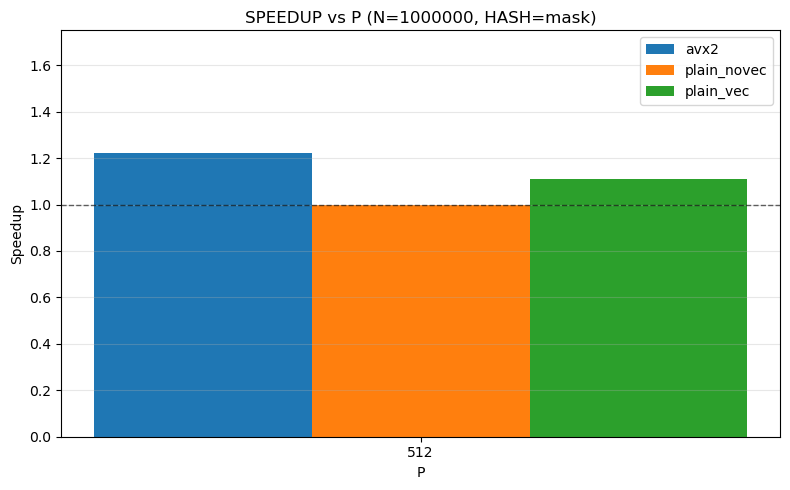

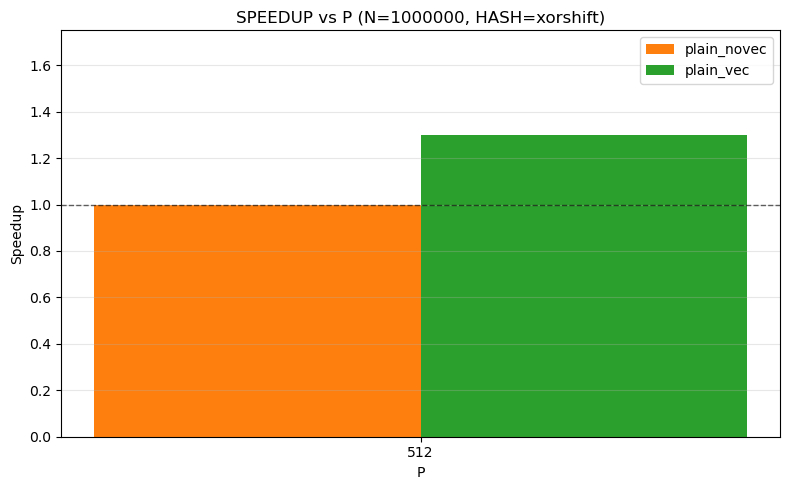

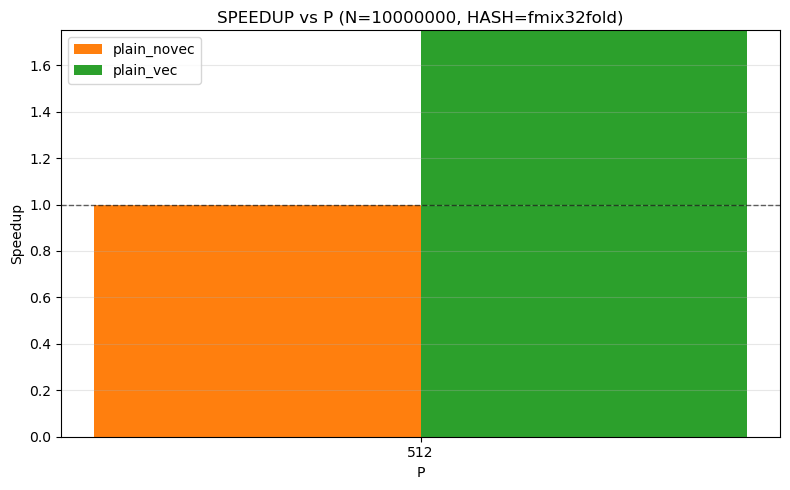

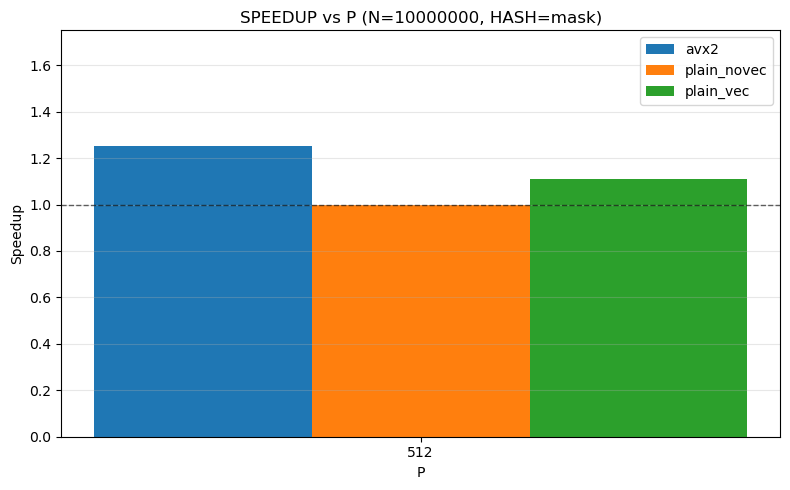

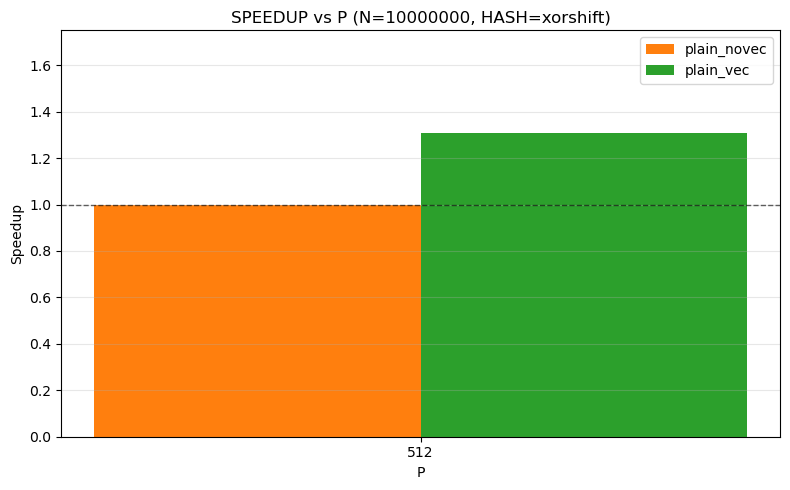

In [48]:
GLOBAL_SPEEDUP_YMAX = speedup_avg_df["SPEEDUP"].max()
for (fixed_N, fixed_HASH), subdf in speedup_avg_df.groupby(["N", "HASH"]):
    plot_df = subdf.sort_values(["P", "EXEC_TYPE"])

    p_values = sorted(plot_df["P"].unique())
    x_positions = list(range(len(p_values)))
    exec_types = sorted(plot_df["EXEC_TYPE"].dropna().unique())

    if not exec_types:
        continue

    bar_width = 0.8 / len(exec_types)

    plt.figure(figsize=(8, 5))

    for idx, exec_type in enumerate(exec_types):
        g = plot_df[plot_df["EXEC_TYPE"] == exec_type].sort_values("P")
        values_by_p = g.set_index("P")["SPEEDUP"].to_dict()
        heights = [values_by_p.get(p, float("nan")) for p in p_values]
        offsets = [
            x + (idx - (len(exec_types) - 1) / 2) * bar_width
            for x in x_positions
        ]

        plt.bar(
            offsets,
            heights,
            width=bar_width,
            color=exec_type_colors.get(exec_type, "tab:gray"),
            label=exec_type,
        )

    if pd.notna(GLOBAL_SPEEDUP_YMAX):
        plt.ylim(0, GLOBAL_SPEEDUP_YMAX)

    plt.axhline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.6)
    plt.xticks(x_positions, p_values)
    plt.xlabel("P")
    plt.ylabel("Speedup")
    plt.title(f"SPEEDUP vs P (N={fixed_N}, HASH={fixed_HASH})")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Throughput

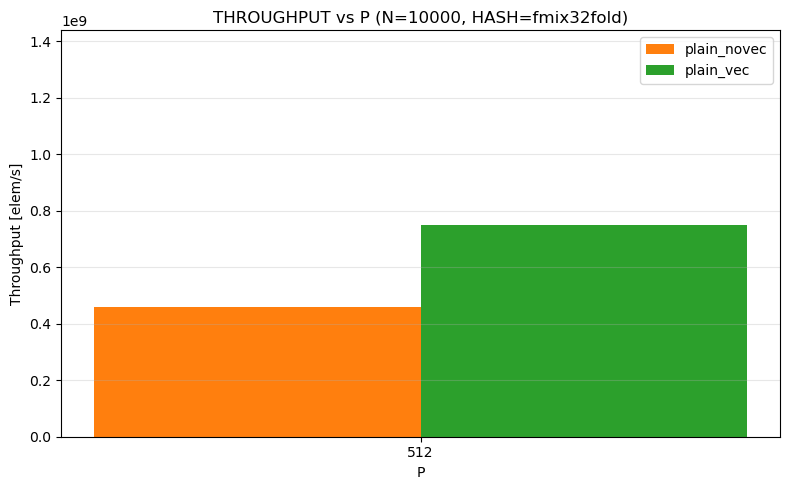

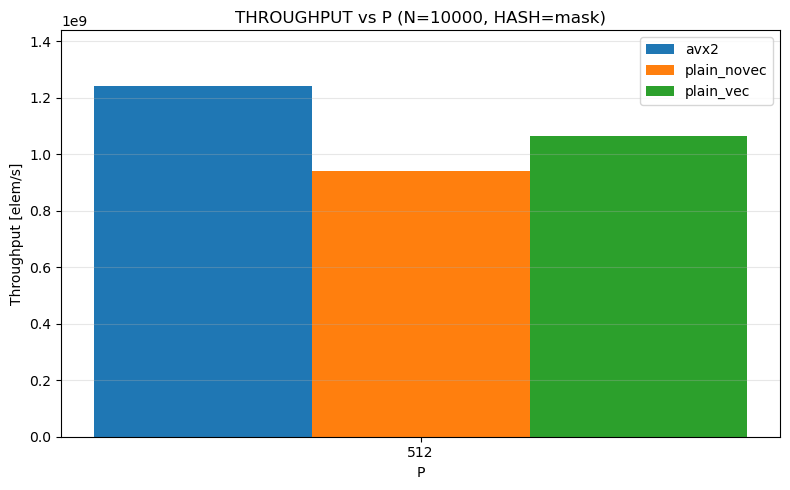

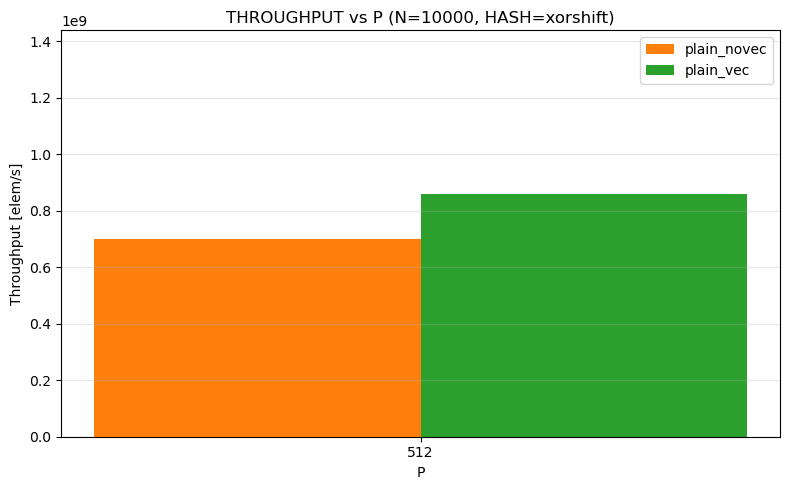

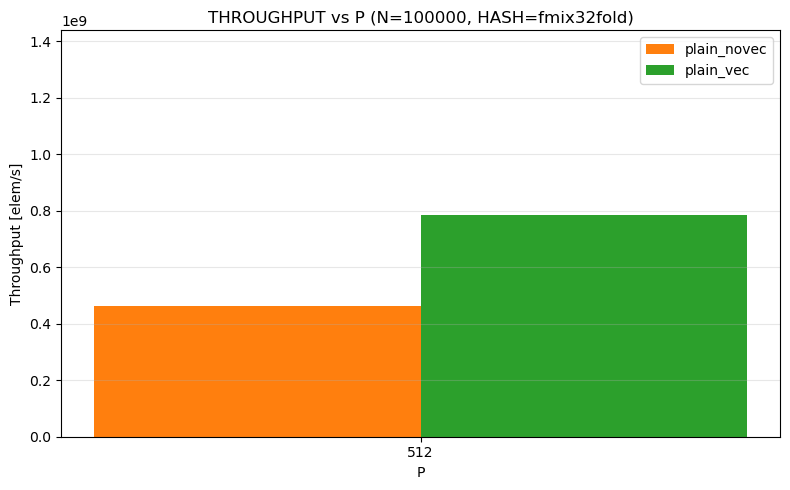

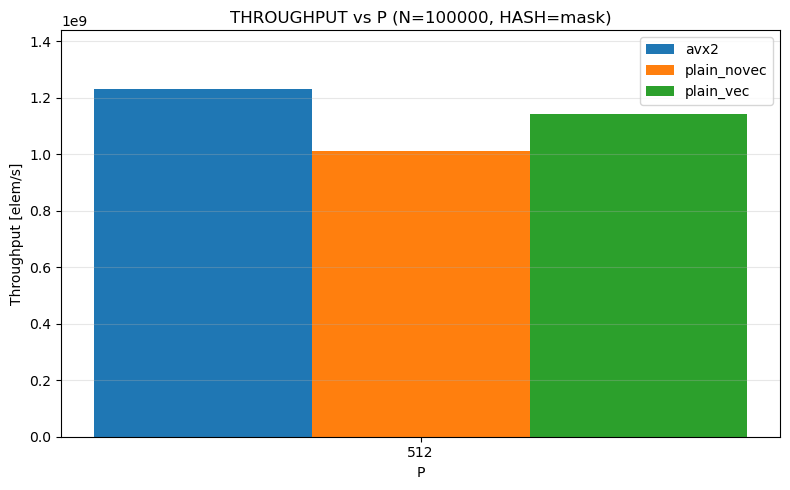

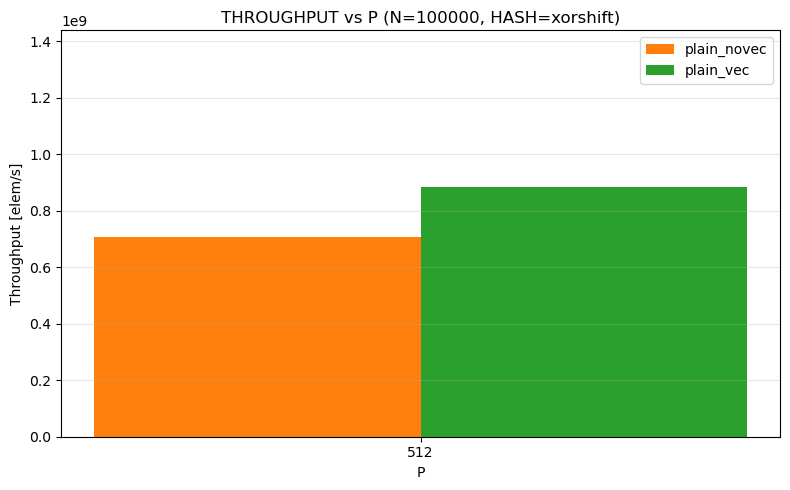

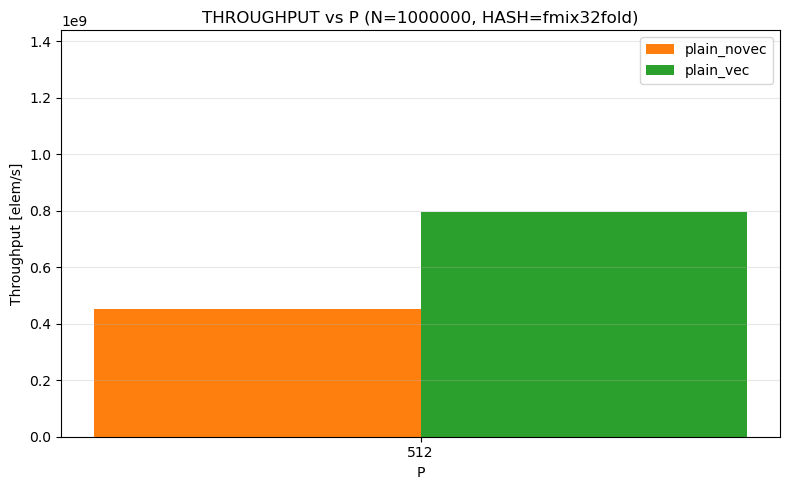

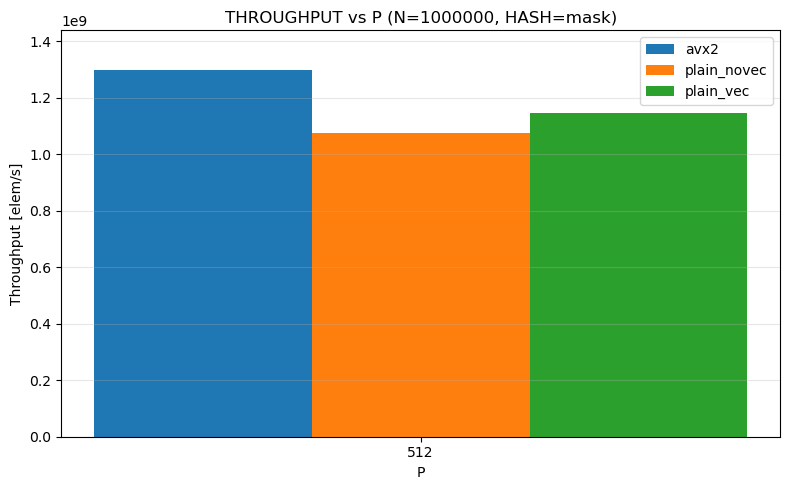

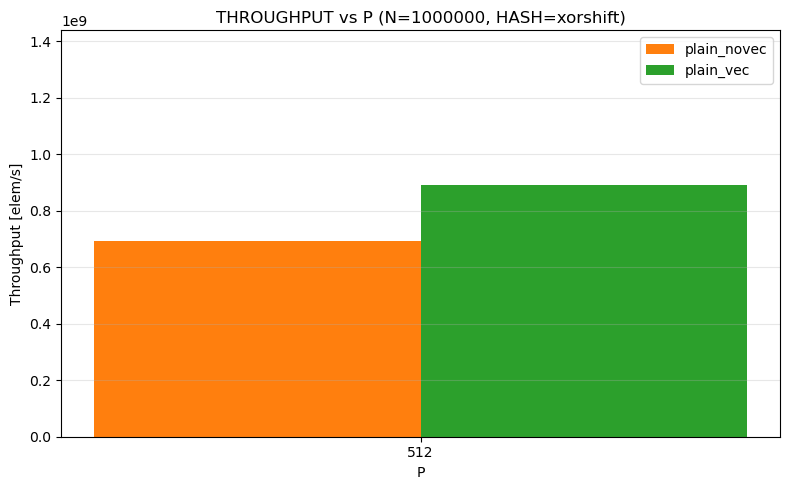

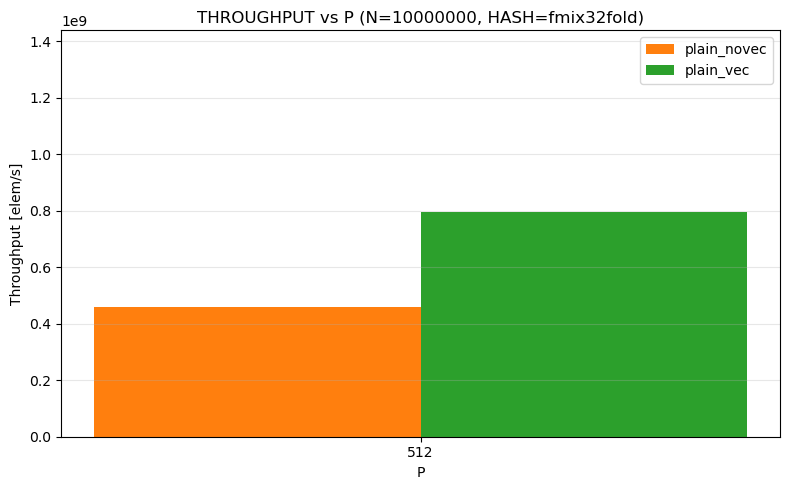

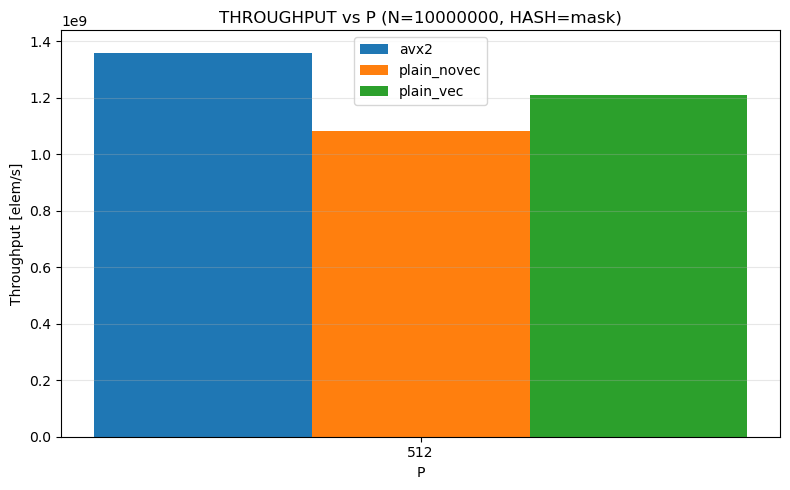

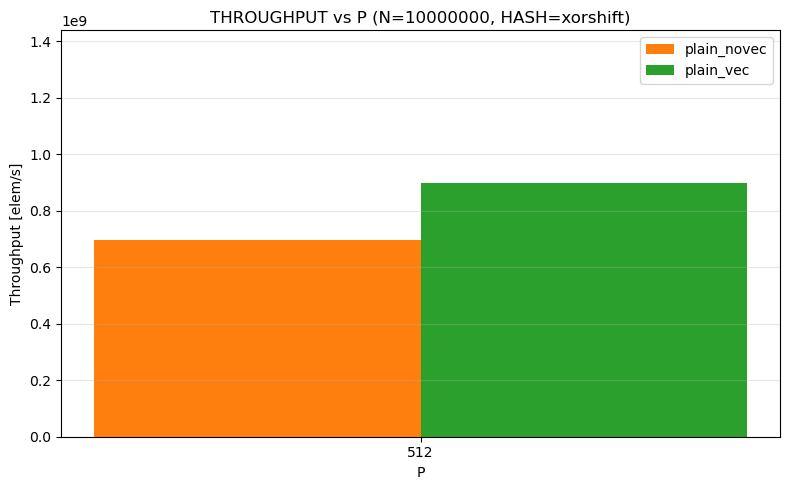

In [49]:
GLOBAL_THROUGHPUT_YMAX = df["THROUGHPUT"].max()
for (fixed_N, fixed_HASH), subdf in df.groupby(["N", "HASH"]):
    plt.figure(figsize=(8, 5))

    p_values = sorted(subdf["P"].unique())
    x_positions = list(range(len(p_values)))
    exec_types = sorted(subdf["EXEC_TYPE"].dropna().unique())

    if not exec_types:
        continue

    bar_width = 0.8 / len(exec_types)
    max_candidates = []

    for idx, exec_type in enumerate(exec_types):
        g = subdf[subdf["EXEC_TYPE"] == exec_type].sort_values("P")
        values_by_p = g.set_index("P")["THROUGHPUT"].to_dict()
        heights = [values_by_p.get(p, float("nan")) for p in p_values]
        offsets = [
            x + (idx - (len(exec_types) - 1) / 2) * bar_width
            for x in x_positions
        ]

        for value in heights:
            if pd.notna(value):
                max_candidates.append(value)

        plt.bar(
            offsets,
            heights,
            width=bar_width,
            color=exec_type_colors.get(exec_type, "tab:gray"),
            label=exec_type,
        )

    if pd.notna(GLOBAL_THROUGHPUT_YMAX):
        plt.ylim(0, GLOBAL_THROUGHPUT_YMAX)

    plt.xticks(x_positions, p_values)
    plt.xlabel("P")
    plt.ylabel("Throughput [elem/s]")
    plt.title(f"THROUGHPUT vs P (N={fixed_N}, HASH={fixed_HASH})")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Throughput over N

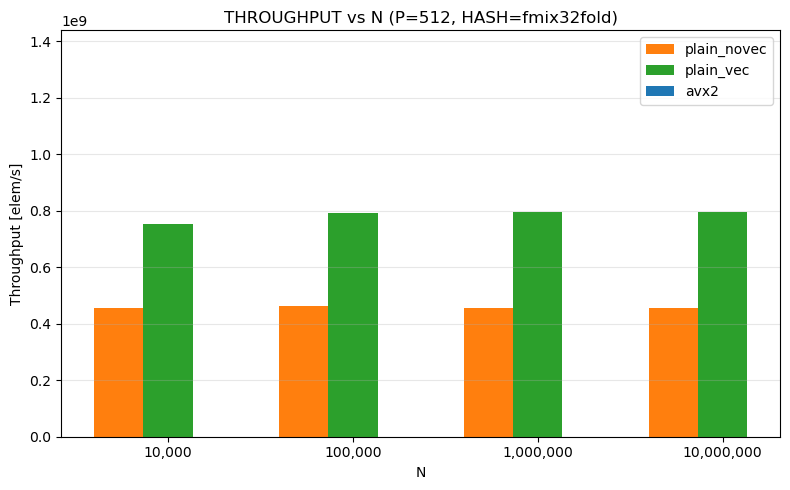

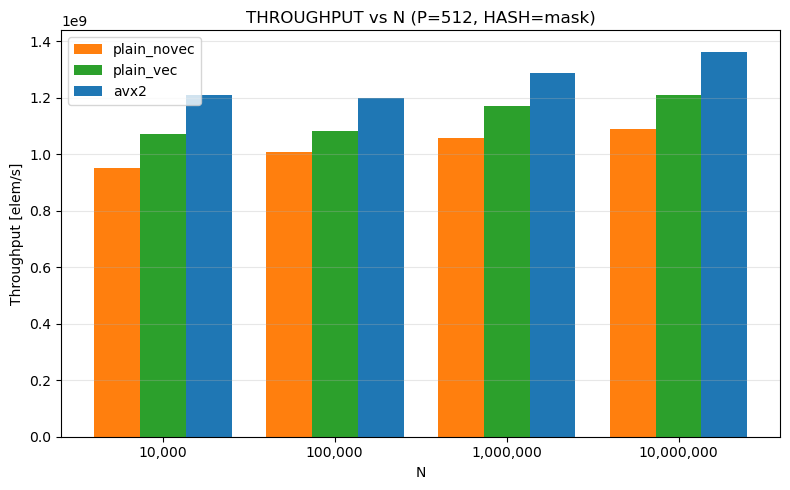

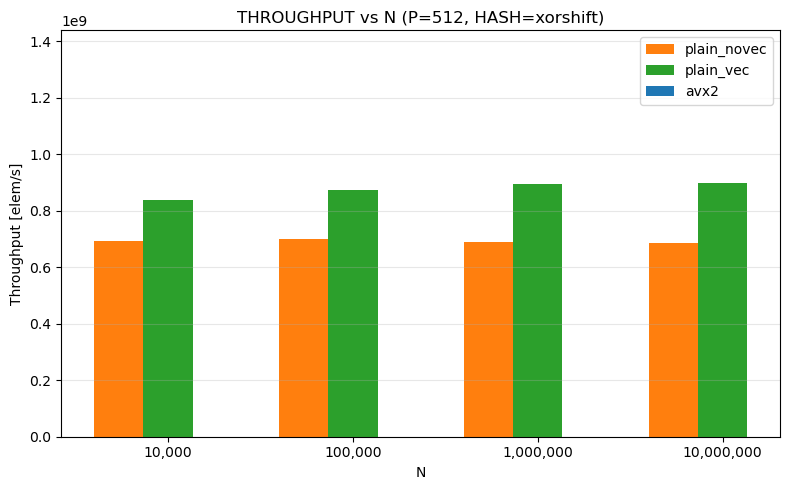

In [50]:
mask_df = df[df["P"] == 512].copy()

exec_order = ["plain_novec", "plain_vec", "avx2"]
exec_types = [et for et in exec_order if et in mask_df["EXEC_TYPE"].dropna().unique()]

throughput_by_cfg = (
    mask_df.groupby(["P", "N", "EXEC_TYPE", "HASH"], as_index=False)
    .agg(mean_throughput=("THROUGHPUT", "mean"))
    .sort_values(["P", "N", "EXEC_TYPE", "HASH"])
)

global_mask_throughput_ymax = mask_df["THROUGHPUT"].max()

for (fixed_P, fixed_HASH), subdf in throughput_by_cfg.groupby(["P", "HASH"], as_index=False):
    plt.figure(figsize=(8, 5))

    n_values = sorted(subdf["N"].unique())
    x_positions = list(range(len(n_values)))

    if not exec_types:
        continue

    bar_width = 0.8 / len(exec_types)

    for idx, exec_type in enumerate(exec_types):
        g = subdf[subdf["EXEC_TYPE"] == exec_type].sort_values("N")
        values_by_n = g.set_index("N")["mean_throughput"].to_dict()
        heights = [values_by_n.get(n, float("nan")) for n in n_values]
        offsets = [
            x + (idx - (len(exec_types) - 1) / 2) * bar_width
            for x in x_positions
        ]

        plt.bar(
            offsets,
            heights,
            width=bar_width,
            color=exec_type_colors.get(exec_type, "tab:gray"),
            label=exec_type,
        )

    if pd.notna(global_mask_throughput_ymax):
        plt.ylim(0, global_mask_throughput_ymax)

    plt.xticks(x_positions, [f"{int(n):,}" for n in n_values])
    plt.xlabel("N")
    plt.ylabel("Throughput [elem/s]")
    plt.title(f"THROUGHPUT vs N (P={fixed_P}, HASH={fixed_HASH})")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()